In [75]:
# Semiconductor Fab Simulation Model

# Structured as a 3-layer system:
# 1. Process Engine
# 2. System Dynamics
# 3. Planning Decisions

In [76]:
# =========================
# SECTION 1: PROCESS ENGINE
# =========================

In [77]:
# Import core libraries for simulation and analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random_seed = 100
np.random.seed(random_seed)

In [78]:
# Number of lots entering the system (simulation scale)
num_lots = 3000

# Semiconductor manufacturing process flow
process_flow = [
    "Litho",
    "Etch",
    "Clean",
    "Test"
]


# Machine processing characteristics (mean = central tendency, std = variability)
stations = {
    "Litho": {
        "mean_process_time": 10,
        "std_process_time": 2,
        "num_tools": 2
    },

    "Etch": {
        "mean_process_time": 15,
        "std_process_time": 3,
        "num_tools": 2
    },

    "Clean": {
        "mean_process_time": 8,
        "std_process_time": 1,
        "num_tools": 1
    },

    "Test": {
        "mean_process_time": 5,
        "std_process_time": 1,
        "num_tools": 1
    }
}

In [79]:
# Generate wafer lots entering the fab
# Each lot represents a work unit flowing through the semiconductor process

lots = pd.DataFrame({
    "lot_id": [f"L{i}" for i in range(num_lots)],

    "arrival_time": np.random.exponential(
        scale=5,
        size=num_lots
    ).cumsum(),

    "priority": np.random.choice(
        ["Normal", "Hot Lot"],
        size=num_lots,
        p=[0.9, 0.1]
    )
})

# Preview generated dataset
lots.head()

,lot_id,arrival_time,priority
0,L0,3.919792,Normal
1,L1,5.551001,Normal
2,L2,8.313734,Normal
3,L3,17.628169,Normal
4,L4,17.651819,Hot Lot


In [80]:
# Simulate each lot going through the semiconductor process flow
# This calculates cycle time based on stochastic processing times

cycle_times = []

for i in range(num_lots):
    
    total_process_time = 0

    # Each lot goes through all process steps sequentially
    for step in process_flow:
        
        # Get machine parameters for current step
        params = stations[step]

        # Sample processing time using normal distribution
        # This introduces variability (realistic manufacturing behavior)
        process_time = np.random.normal(
            params["mean_process_time"],
            params["std_process_time"]
        )

        # Ensure no negative processing time
        process_time = max(0, process_time)

        total_process_time += process_time

    cycle_times.append(total_process_time)

# Add results to dataframe
lots["cycle_time"] = cycle_times

# Preview result
lots.head()

,lot_id,arrival_time,priority,cycle_time
0,L0,3.919792,Normal,38.444038
1,L1,5.551001,Normal,38.873689
2,L2,8.313734,Normal,40.876499
3,L3,17.628169,Normal,35.032654
4,L4,17.651819,Hot Lot,35.939512


In [99]:
# While process times define local variability, system behavior emerges when multiple lots interact under finite capacity.

In [81]:
# =========================
# SECTION 2: SYSTEM DYNAMICS
# =========================

In [82]:
# Cycle Time KPI + System Risk Assessment

print("Cycle Time Statistics (Descriptive View)")
print(lots["cycle_time"].describe())

print("\n" + "="*50)
print("Planning Key Metrics")

mean_ct = lots["cycle_time"].mean()
std_ct = lots["cycle_time"].std()
cv = std_ct / mean_ct

p90 = np.percentile(lots["cycle_time"], 90)
p95 = np.percentile(lots["cycle_time"], 95)

print(f"Mean Cycle Time: {mean_ct:.2f}")
print(f"Std Cycle Time: {std_ct:.2f}")
print(f"CV (Variability Index): {cv:.3f}")

print(f"P90 Cycle Time: {p90:.2f}")
print(f"P95 Cycle Time: {p95:.2f}")

print("\nPlanning Interpretation:")

if cv < 0.10:
    risk_level = "Low variability system (stable planning environment)"
elif cv < 0.20:
    risk_level = "Moderate variability system (buffer required)"
else:
    risk_level = "High variability system (risk of schedule slippage)"

print(f"- System Risk Level: {risk_level}")
print("- P90/P95 define planning buffers for capacity commitment")
print("- Mean alone is insufficient for production planning decisions")

Cycle Time Statistics (Descriptive View)
count    3000.000000
mean       37.981494
std         3.814410
min        21.605904
25%        35.497323
50%        37.910331
75%        40.621236
max        51.551981
Name: cycle_time, dtype: float64

Planning Key Metrics
Mean Cycle Time: 37.98
Std Cycle Time: 3.81
CV (Variability Index): 0.100
P90 Cycle Time: 42.85
P95 Cycle Time: 44.03

Planning Interpretation:
- System Risk Level: Moderate variability system (buffer required)
- P90/P95 define planning buffers for capacity commitment
- Mean alone is insufficient for production planning decisions


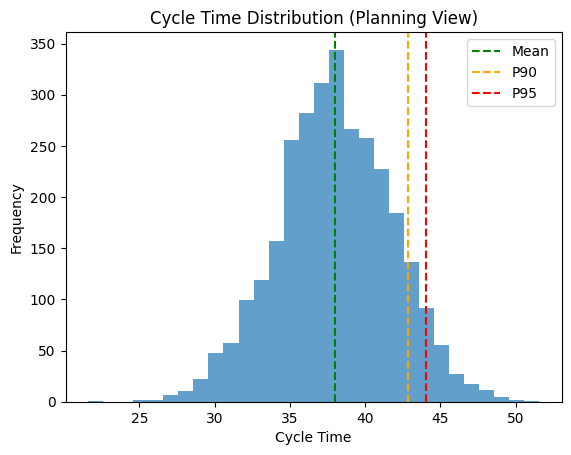


Planning Buffer Analysis:
P90 Buffer: 4.87 (12.81%)
P95 Buffer: 6.05 (15.92%)

Planning Interpretation:
- P90 buffer → safe planning margin
- P95 buffer → risk protection margin

- Significant capacity buffer required
- Planning must rely on tail-risk (P95), not mean


In [83]:
# Planning Buffer Analysis (Tail Risk Interpretation)

import numpy as np
import matplotlib.pyplot as plt

# Distribution view (planning perspective)
plt.hist(lots["cycle_time"], bins=30, alpha=0.7)

plt.axvline(mean_ct, color='green', linestyle='dashed', label='Mean')
plt.axvline(p90, color='orange', linestyle='dashed', label='P90')
plt.axvline(p95, color='red', linestyle='dashed', label='P95')

plt.title("Cycle Time Distribution (Planning View)")
plt.xlabel("Cycle Time")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Buffer Calculation

buffer_p90 = p90 - mean_ct
buffer_p95 = p95 - mean_ct

print("\nPlanning Buffer Analysis:")

print(f"P90 Buffer: {buffer_p90:.2f} ({buffer_p90/mean_ct:.2%})")
print(f"P95 Buffer: {buffer_p95:.2f} ({buffer_p95/mean_ct:.2%})")

print("\nPlanning Interpretation:")

print(f"- P90 buffer → safe planning margin")
print(f"- P95 buffer → risk protection margin")

# Decision Rule

if buffer_p95 / mean_ct > 0.15:
    print("\nWARNING: High variability system detected")
    print("- Significant capacity buffer required")
    print("- Planning must rely on tail-risk (P95), not mean")
else:
    print("\nSystem is within acceptable variability range")

In [84]:
# System Bottleneck + Stability Analysis (Queue-aware Planning View)

import numpy as np
import pandas as pd

# Step 1: Station Capacity Model

capacity = {}

for station, params in stations.items():
    
    mean_time = params["mean_process_time"]
    tools = params["num_tools"]
    
    # Effective processing capacity (lots per unit time)
    capacity[station] = tools / mean_time


capacity_df = pd.DataFrame.from_dict(
    capacity,
    orient="index",
    columns=["capacity"]
)

print("=== Station Capacity Profile ===")
print(capacity_df)


# Step 2: Bottleneck Identification

bottleneck = min(capacity, key=capacity.get)

print("\n=== Bottleneck Analysis ===")
print(f"Bottleneck Station: {bottleneck}")


# Step 3: System Load (Arrival Pressure Proxy)

arrival_rate = 1 / 5   # from exponential(scale=5)

utilization = {}

for station in stations:
    
    station_capacity = capacity[station]
    utilization[station] = arrival_rate / station_capacity


utilization_df = pd.DataFrame.from_dict(
    utilization,
    orient="index",
    columns=["utilization"]
)

print("\n=== Utilization Profile ===")
print(utilization_df)


# Step 4: System Stability Classification

max_util = max(utilization.values())

print("\n=== System Stability Diagnosis ===")

if max_util < 0.7:
    system_state = "Stable"
    print("- System Status: Stable")
    print("- Low WIP accumulation expected")

elif max_util < 1.0:
    system_state = "At Risk"
    print("- System Status: At Risk")
    print("- Queue buildup likely at bottleneck")

else:
    system_state = "Unstable"
    print("- System Status: UNSTABLE (Queue Explosion Risk)")
    print("- System is no longer capacity-limited, but congestion-driven")


# Step 5: Planning Insight 

print("\n=== Planning Interpretation ===")

print("- Bottleneck is not static; it becomes system-dominant under high load")
print("- Utilization near or above 1 causes nonlinear cycle time growth")
print("- Capacity expansion alone cannot fix queue-driven delay")

if system_state == "Unstable":
    print("- ACTION: reduce load OR increase bottleneck capacity")
    print("- PRIORITY: stabilize bottleneck station first")

=== Station Capacity Profile ===
       capacity
Litho  0.200000
Etch   0.133333
Clean  0.125000
Test   0.200000

=== Bottleneck Analysis ===
Bottleneck Station: Clean

=== Utilization Profile ===
       utilization
Litho          1.0
Etch           1.5
Clean          1.6
Test           1.0

=== System Stability Diagnosis ===
- System Status: UNSTABLE (Queue Explosion Risk)
- System is no longer capacity-limited, but congestion-driven

=== Planning Interpretation ===
- Bottleneck is not static; it becomes system-dominant under high load
- Utilization near or above 1 causes nonlinear cycle time growth
- Capacity expansion alone cannot fix queue-driven delay
- ACTION: reduce load OR increase bottleneck capacity
- PRIORITY: stabilize bottleneck station first


In [98]:
# NOTE: System-level behavior emerges from queue interaction, not process time alone.

In [86]:
# WIP + Queue Accumulation Simulation (System State View)

import numpy as np
import pandas as pd

# Initialize WIP tracking

wip = {station: 0 for station in process_flow}
wip_history = []

arrival_rate = 1 / 5

# Time step simulation (simplified steady-state proxy)

time_steps = 200

for t in range(time_steps):
    
    # arrivals into system
    arrivals = np.random.poisson(arrival_rate)
    wip["Litho"] += arrivals   # all jobs enter first station

    # process flow propagation
    for station in process_flow:
        
        params = stations[station]
        capacity = params["num_tools"] / params["mean_process_time"]
        
        processed = min(wip[station], capacity)
        wip[station] -= processed
        
        # push to next station
        if station != process_flow[-1]:
            next_station = process_flow[process_flow.index(station) + 1]
            wip[next_station] += processed

    wip_history.append(wip.copy())

# Convert to dataframe

wip_df = pd.DataFrame(wip_history)

print("=== Average WIP per Station ===")
print(wip_df.mean())

=== Average WIP per Station ===
Litho    2.765000
Etch     2.202667
Clean    0.358583
Test     0.000000
dtype: float64


In [100]:
# Once system congestion emerges, planning must shift from average-based metrics to tail-risk metrics (P90/P95)

In [ ]:
# =========================
# SECTION 3: PLANNING DECISIONS
# =========================

In [87]:
# Scenario-based Sensitivity Analysis (Planning Decision Model)

import numpy as np
import pandas as pd

def run_simulation(var_multiplier=1.0, bottleneck=None, capacity_boost=None):
    
    cycle_times = []
    
    for i in range(num_lots):
        
        total_process_time = 0
        
        for step in process_flow:
            
            params = stations[step]
            
            mean = params["mean_process_time"]
            std = params["std_process_time"] * var_multiplier
            
            # Capacity effect (simple proxy: reduce effective time if more tools)
            if capacity_boost == step:
                mean = mean * 0.95  # 5% efficiency gain proxy
            
            process_time = np.random.normal(mean, std)
            process_time = max(0, process_time)
            
            total_process_time += process_time
        
        cycle_times.append(total_process_time)
    
    cycle_times = np.array(cycle_times)
    
    return {
        "mean": np.mean(cycle_times),
        "p90": np.percentile(cycle_times, 90),
        "p95": np.percentile(cycle_times, 95)
    }


# Baseline

baseline = run_simulation()

# Scenarios

scenarios = {
    "Baseline": baseline,
    "High Variability (+50%)": run_simulation(var_multiplier=1.5),
    "Litho Capacity Improvement": run_simulation(capacity_boost="Litho"),
    "Etch Capacity Improvement": run_simulation(capacity_boost="Etch"),
}

# Results

results = pd.DataFrame(scenarios).T

results["P90 Impact"] = results["p90"] - baseline["p90"]
results["P95 Impact"] = results["p95"] - baseline["p95"]

results

,mean,p90,p95,P90 Impact,P95 Impact
Baseline,37.905431,42.876420,44.330367,0.000000,0.000000
High Variability (+50%),38.106238,45.589772,47.475901,2.713352,3.145534
Litho Capacity Improvement,37.561081,42.523140,43.791439,-0.353280,-0.538927
Etch Capacity Improvement,37.259957,42.318543,43.496035,-0.557877,-0.834331


In [88]:
# Scenario Comparison 

import pandas as pd

# Ensure clean numeric format
results = results.copy()

# Delta vs baseline
baseline_mean = results.loc["Baseline", "mean"]
baseline_p90 = results.loc["Baseline", "p90"]
baseline_p95 = results.loc["Baseline", "p95"]

results["Mean Delta"] = results["mean"] - baseline_mean
results["P90 Delta"] = results["p90"] - baseline_p90
results["P95 Delta"] = results["p95"] - baseline_p95

# % impact (planning normalized view)
results["P90 Impact %"] = results["P90 Delta"] / baseline_p90
results["P95 Impact %"] = results["P95 Delta"] / baseline_p95

# Ranking by planning risk impact (P95 as key metric)
ranked = results.sort_values("P95 Delta", ascending=False)

print("=== Scenario Impact Ranking (P95 Risk Priority) ===\n")
print(ranked[["mean", "p90", "p95", "P95 Delta", "P95 Impact %"]])

print("\n=== Key Planning Insight ===")

most_impactful = ranked.index[0]
least_impactful = ranked.index[-1]

print(f"- Primary risk driver: {most_impactful}")
print(f"- Lowest impact scenario: {least_impactful}")
print("\nNote:")
print("- Scenario ranking is relative to current simulation assumptions")
print("- Results should be only interpreted as directional impact")

print("\nDecision Interpretation:")

# decision logic
if "Variability" in most_impactful:
    print("- System is sensitivity-dominated by PROCESS VARIABILITY")
    print("- Priority action: reduce process variance (SPC / tool stability / recipe tuning)")
    print("- Capacity expansion alone is NOT sufficient for risk control")
else:
    print("- System is capacity-dominated")
    print("- Priority action: increase tool capacity or reduce bottleneck load")

print("\nPlanning Rule (Key Takeaway):")
print("- P95 is the governing metric for commit-level planning")
print("- Mean-based optimization underestimates delivery risk")
print("- Best ROI comes from reducing tail-risk drivers, not average improvement")

=== Scenario Impact Ranking (P95 Risk Priority) ===

                                 mean        p90        p95  P95 Delta  \
High Variability (+50%)     38.106238  45.589772  47.475901   3.145534   
Baseline                    37.905431  42.876420  44.330367   0.000000   
Litho Capacity Improvement  37.561081  42.523140  43.791439  -0.538927   
Etch Capacity Improvement   37.259957  42.318543  43.496035  -0.834331   

                            P95 Impact %  
High Variability (+50%)         0.070957  
Baseline                        0.000000  
Litho Capacity Improvement     -0.012157  
Etch Capacity Improvement      -0.018821  

=== Key Planning Insight ===
- Primary risk driver: High Variability (+50%)
- Lowest impact scenario: Etch Capacity Improvement

Note:
- Scenario ranking is relative to current simulation assumptions
- Results should be only interpreted as directional impact

Decision Interpretation:
- System is sensitivity-dominated by PROCESS VARIABILITY
- Priority action:

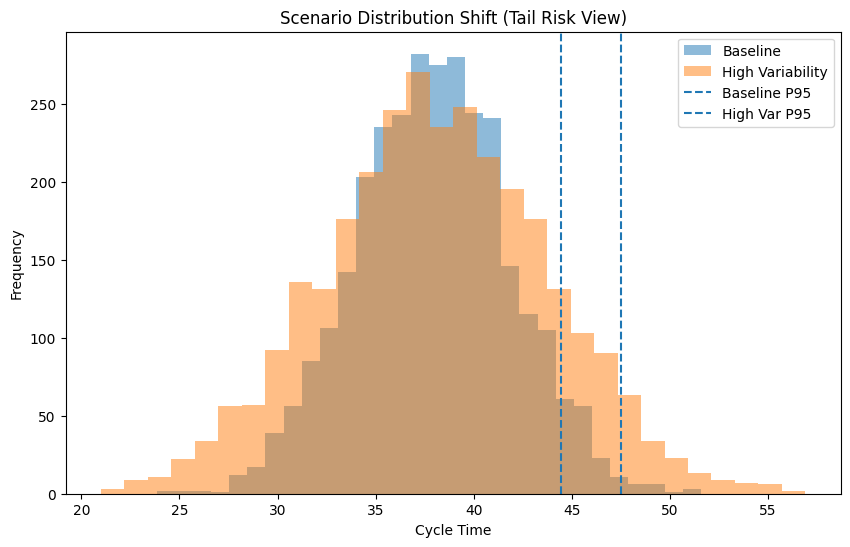

In [89]:
import matplotlib.pyplot as plt

# Extract scenarios from results engine
# Re-run lightweight sampling for visualization consistency

def get_distribution(var_multiplier=1.0):
    cycle_times = []
    
    for i in range(num_lots):
        total = 0
        
        for step in process_flow:
            params = stations[step]
            
            mean = params["mean_process_time"]
            std = params["std_process_time"] * var_multiplier
            
            process_time = np.random.normal(mean, std)
            process_time = max(0, process_time)
            total += process_time
        
        cycle_times.append(total)
    
    return cycle_times


baseline_ct = get_distribution(1.0)
high_var_ct = get_distribution(1.5)

# Plot
plt.figure(figsize=(10,6))

plt.hist(baseline_ct, bins=30, alpha=0.5, label="Baseline")
plt.hist(high_var_ct, bins=30, alpha=0.5, label="High Variability")

# P95 lines
plt.axvline(np.percentile(baseline_ct, 95), linestyle="dashed", label="Baseline P95")
plt.axvline(np.percentile(high_var_ct, 95), linestyle="dashed", label="High Var P95")

plt.title("Scenario Distribution Shift (Tail Risk View)")
plt.xlabel("Cycle Time")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [102]:
# System performance is therefore not a property of machines, but a property of system interactions under load.

In [90]:
# SYSTEM FINAL SNAPSHOT

import numpy as np
import pandas as pd

print("=== SYSTEM SNAPSHOT ===\n")

# 1. Cycle Time Summary

mean_ct = lots["cycle_time"].mean()
p90 = np.percentile(lots["cycle_time"], 90)
p95 = np.percentile(lots["cycle_time"], 95)

print("Cycle Time Metrics:")
print(f"- Mean: {mean_ct:.2f}")
print(f"- P90 : {p90:.2f}")
print(f"- P95 : {p95:.2f}\n")

# 2. Rebuild capacity safely 

capacity_dict = {
    station: params["num_tools"] / params["mean_process_time"]
    for station, params in stations.items()
}

bottleneck_station = min(capacity_dict, key=capacity_dict.get)

print("Bottleneck Analysis:")
print(f"- Bottleneck Station: {bottleneck_station}\n")

# 3. Utilization summary

arrival_rate = 1 / 5

utilization = {
    station: arrival_rate / cap
    for station, cap in capacity_dict.items()
}

max_util = max(utilization.values())

print("System Load:")
print(f"- Max Utilization: {max_util:.2f}")

# 4. WIP summary (safe from Cell 11)

avg_wip = wip_df.mean().max()

print("\nWIP Summary:")
print(f"- Peak Avg WIP (station-level): {avg_wip:.2f}")

# 5. Final System Health

print("\nSystem Health:")

if max_util < 0.7:
    health = "STABLE"
elif max_util < 1.0:
    health = "AT RISK"
else:
    health = "UNSTABLE"

print(f"- Status: {health}")

# 6. Final interpretation

print("\nKey Insight:")
print("- Bottleneck drives system behavior")
print("- Utilization drives queue explosion")
print("- WIP confirms congestion level")
print("- P95 is planning-critical metric")

=== SYSTEM SNAPSHOT ===

Cycle Time Metrics:
- Mean: 37.98
- P90 : 42.85
- P95 : 44.03

Bottleneck Analysis:
- Bottleneck Station: Clean

System Load:
- Max Utilization: 1.60

WIP Summary:
- Peak Avg WIP (station-level): 2.76

System Health:
- Status: UNSTABLE

Key Insight:
- Bottleneck drives system behavior
- Utilization drives queue explosion
- WIP confirms congestion level
- P95 is planning-critical metric
